In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re

In [26]:
# some statements to make the figures look nicer
%config InlineBackend.figure_format='retina'
plt.rcParams.update({'axes.linewidth' : 1,
                     'ytick.major.width' : 1,
                     'ytick.minor.width' : 1,
                     'xtick.major.width' : 1,
                     'xtick.minor.width' : 1,
                     'xtick.labelsize': 10,
                     'ytick.labelsize': 10,
                     'axes.labelsize': 12,
                     'font.family': 'Serif',
                     'figure.figsize': (10, 6)
                    })

In [27]:
TIME_PATTERN = re.compile(r"Time:\s*([0-9]*\.?[0-9]+)\s*sec", re.IGNORECASE)
REFERENCE_PATTERN = re.compile(r"Reference time:\s*([0-9]*\.?[0-9]+)\s*sec", re.IGNORECASE)
MISMATCH_PATTERN = re.compile(r"Total mismatches:\s*(\d+)", re.IGNORECASE)

In [32]:
def get_graph_statistics(stat_path: str):
    num_vertices = 0
    num_edges = 0
    name = ""
    with open(stat_path, 'r') as f:
        for line in f:
            if line.startswith("Name:"):
                name = line.split(":")[1].strip()
            if line.startswith("Vertices:"):
                num_vertices = int(line.split(":")[1].strip())
            elif line.startswith("Edges:"):
                num_edges = int(line.split(":")[1].strip())
    return name, num_vertices, num_edges

In [33]:
def parse_cpp_output(output: str):
    # Extract all solver times
    times = [float(t) for t in TIME_PATTERN.findall(output)]
    total_time = float(np.sum(times)) if times else 0.0
    mean_time = float(np.mean(times)) if times else 0.0

    # Reference time speedup
    reference_time_match = REFERENCE_PATTERN.search(output)
    reference_time = float(reference_time_match.group(1)) if reference_time_match else None
    speedup = reference_time / total_time if reference_time and total_time > 0 else 0

    return total_time, mean_time, speedup

In [34]:
# Hyperparameters
output_dir = 'output/2026-03-30-10:26:38'

In [35]:
def get_all_algorithms(output_dir: str):
    algorithms = set()
    for filename in os.listdir(output_dir):
        if filename.endswith('.txt') and filename != "graph_stats.txt":
            alg_name = filename.split('_')[0]
            algorithms.add(alg_name)
    return sorted(algorithms)

def get_all_test_sizes(output_dir: str, algorithm: str):
    test_sizes = set()
    for filename in os.listdir(output_dir):
        if filename.startswith(algorithm) and filename.endswith('.txt'):
            size_part = filename.split('_')[1].split('.')[0]
            if size_part.isdigit():
                test_sizes.add(int(size_part))
    return sorted(test_sizes)

# Find the algorithms 
algorithms = get_all_algorithms(output_dir)
test_sizes = get_all_test_sizes(output_dir, algorithms[0])  # Assuming all algorithms have the same test sizes
name, num_vertices, num_edges = get_graph_statistics(os.path.join(output_dir, "graph_stats.txt"))

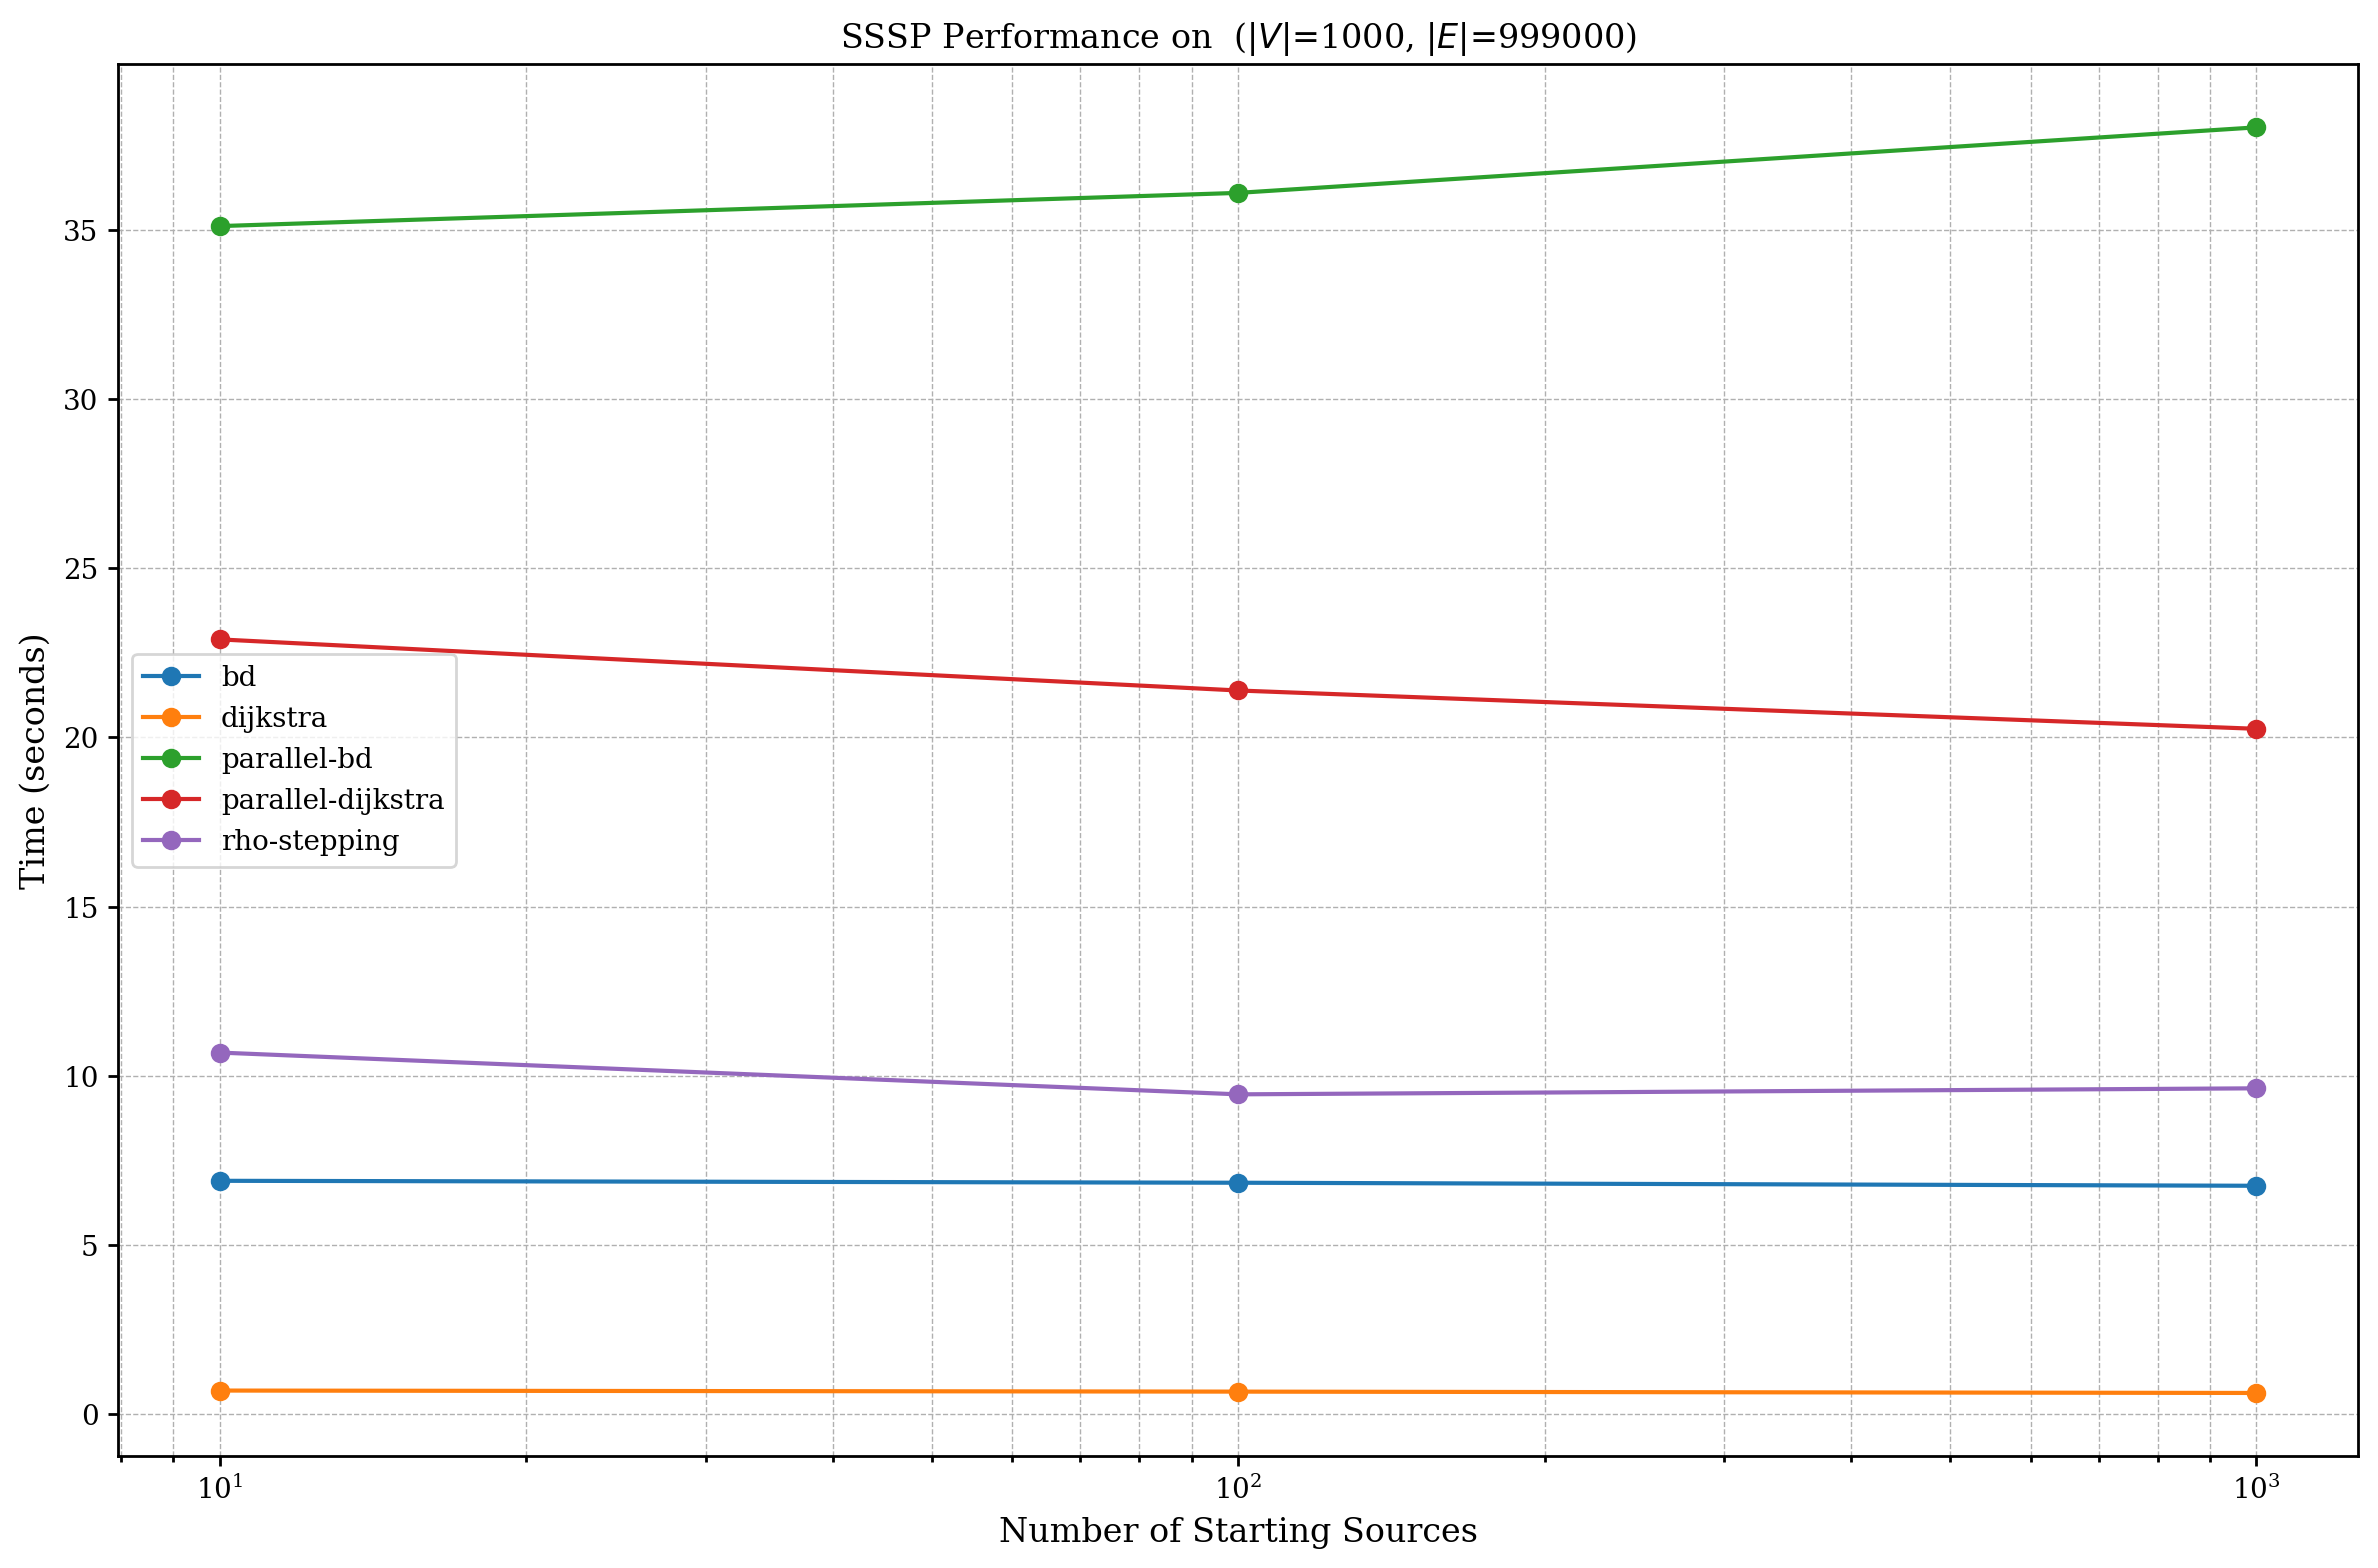

In [37]:
# Per graph we start from N sources, where N increases from 10 to 1000. The files are correspondingly output/{curr_time}/dijkstra_10.txt, output/{curr_time}/dijkstra_100.txt, etc. We want to parse these files and extract the total time, mean time, and speedup compared to reference time. We also want to extract the number of mismatches if available.
plt.figure(figsize=(12, 8))
plt.title(f"SSSP Performance on {name} ($|V|$={num_vertices}, $|E|$={num_edges})")
plt.xlabel("Number of Starting Sources")
plt.ylabel("Time (seconds)")
plt.xscale('log')
plt.grid(True, which="both", ls="--", linewidth=0.5)

for alg in algorithms:
    times = []
    speedups = []
    for N in test_sizes:
        file_path = f"{output_dir}/{alg}_{N}.txt"
        if os.path.exists(file_path):
            with open(file_path, 'r') as f:
                output = f.read()
                total_time, mean_time, speedup = parse_cpp_output(output)
                times.append(total_time)
                speedups.append(speedup)
        else:
            times.append(None)
            speedups.append(None)

    plt.plot(test_sizes, times, marker='o', label=f"{alg}")

plt.legend()
plt.tight_layout()
plt.savefig("sssp_performance.png", dpi=300)
plt.show()
